# 01 · Exploring CLINC150

What the data looks like before we model it. Every number here comes from `intentbench.data.load_splits()`, the same loader every approach uses.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from intentbench.data import SEED, load_splits

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 80)

s = load_splits()
splits = {"train": s.train, "validation": s.validation, "test": s.test}

## 1. Examples per split

In [2]:
pd.DataFrame(
    {
        name: {
            "examples": len(df),
            "in-scope": int((df.label != s.oos_id).sum()),
            "out-of-scope": int((df.label == s.oos_id).sum()),
            "oos share": f"{(df.label == s.oos_id).mean():.1%}",
        }
        for name, df in splits.items()
    }
).T

,examples,in-scope,out-of-scope,oos share
train,15201,14951,250,1.6%
validation,3096,2996,100,3.2%
test,5500,4500,1000,18.2%


In [3]:
print(
    "Leaked near-duplicates removed: train",
    s.removed_from_train,
    "| validation",
    s.removed_from_validation,
)

Leaked near-duplicates removed: train 49 | validation 4


## 2. Class balance

Examples per in-scope intent. If min and max are equal, the classes are perfectly balanced and a chart would just be 150 identical bars, so a table says it better.

In [4]:
balance = {}
for name, df in splits.items():
    counts = df[df.label != s.oos_id].intent.value_counts()
    balance[name] = {
        "intents": counts.size,
        "min": counts.min(),
        "median": int(counts.median()),
        "max": counts.max(),
    }
pd.DataFrame(balance).T

,intents,min,median,max
train,150,92,100,100
validation,150,19,20,20
test,150,30,30,30


In [5]:
# Which intents lost training rows to the leakage removal?
counts = s.train[s.train.label != s.oos_id].intent.value_counts()
counts[counts < 100].sort_values()

intent
greeting               92
goodbye                92
no                     93
how_old_are_you        97
what_song              97
thank_you              97
what_is_your_name      98
restaurant_reviews     98
maybe                  98
whisper_mode           99
freeze_account         99
w2                     99
todo_list              99
report_lost_card       99
yes                    99
mpg                    99
repeat                 99
credit_score           99
accept_reservations    99
current_location       99
Name: count, dtype: int64

## 3. Query length (words)

In [6]:
lengths = pd.DataFrame(
    {name: df.text.str.split().str.len().describe() for name, df in splits.items()}
).T.round(1)
lengths

,count,mean,std,min,25%,50%,75%,max
train,15201.0,8.3,3.2,1.0,6.0,8.0,10.0,28.0
validation,3096.0,8.3,3.4,1.0,6.0,8.0,10.0,24.0
test,5500.0,8.3,3.2,1.0,6.0,8.0,10.0,25.0


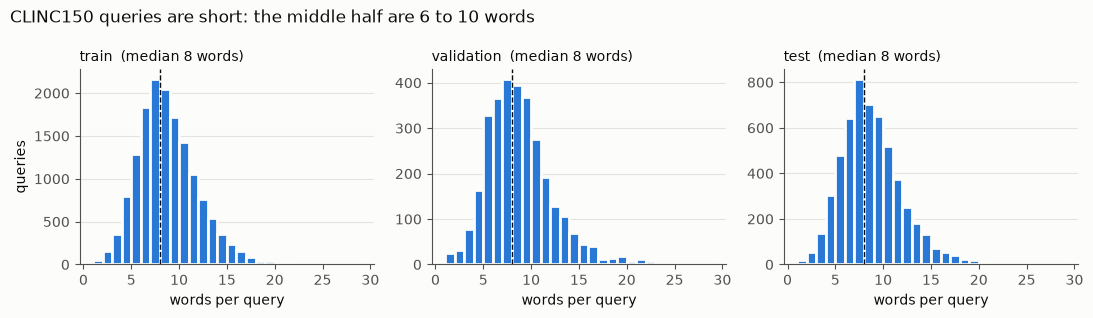

In [7]:
INK, MUTED, SURFACE, SERIES = "#0b0b0b", "#52514e", "#fcfcfb", "#2a78d6"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
bins = range(1, 30)
for ax, (name, df) in zip(axes, splits.items(), strict=True):
    n_words = df.text.str.split().str.len()
    ax.hist(n_words, bins=bins, color=SERIES, edgecolor=SURFACE, linewidth=2)
    ax.axvline(n_words.median(), color=INK, linewidth=1, linestyle="--")
    ax.set_title(f"{name}  (median {n_words.median():.0f} words)", loc="left", fontsize=10)
    ax.set_xlabel("words per query")
    ax.grid(axis="y", color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].set_ylabel("queries")
fig.suptitle(
    "CLINC150 queries are short: the middle half are 6 to 10 words", x=0.01, ha="left", fontsize=12
)
fig.tight_layout()
fig.savefig(FIGURES / "query_length.png", dpi=150)
plt.show()

In [8]:
# Are out-of-scope queries a different length from in-scope ones?
n_words = s.test.text.str.split().str.len()
n_words.groupby(s.test.label == s.oos_id).describe().rename(
    index={False: "in-scope", True: "out-of-scope"}
).round(1)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
in-scope,4500.0,8.2,3.2,1.0,6.0,8.0,10.0,25.0
out-of-scope,1000.0,8.7,2.9,1.0,7.0,8.0,10.0,20.0


## 4. Twenty example rows (train, fixed sample)

In [9]:
s.train.sample(20, random_state=SEED)[["text", "intent"]].reset_index(drop=True)

,text,intent
0,much obliged,thank_you
1,during what month will my card's expiration date fall on,expiration_date
2,are there any meetings i have today,meeting_schedule
3,can i call you betty,change_ai_name
4,what is my intetest rate,interest_rate
5,can you please start my car,smart_home
6,my card is damaged and no longer function,damaged_card
7,when can you send me a replacement card,replacement_card_duration
8,what is the the exchange rate for us dollars to euros,exchange_rate
9,please put africa by toto on my playlist,update_playlist


## 5. Ten out-of-scope examples (train)

In [10]:
s.train[s.train.label == s.oos_id].sample(10, random_state=SEED)[["text"]].reset_index(drop=True)

,text
0,what do the values of numbers mean non-numerically
1,any headlines from my areai
2,what animals have alpha males
3,which marvel character has appeared in the most movies
4,how do you store my card information
5,how much is the best vpn
6,are hawks domesticated or wild
7,where are the oscar's held
8,what is the most popular airline
9,is there a video-on-demand function (vod)


## 6. Intents that look alike

Pairs of intent names that share a word. These are candidates for confusion later; Phase 6 checks whether models actually confuse them.

In [11]:
from collections import defaultdict

by_word = defaultdict(list)
for name in s.labels:
    for word in name.split("_"):
        if len(word) > 3:
            by_word[word].append(name)
{w: names for w, names in sorted(by_word.items()) if len(names) >= 3}

{'balance': ['bill_balance', 'balance', 'rewards_balance', 'pto_balance'],
 'bill': ['bill_balance', 'bill_due', 'pay_bill'],
 'card': ['report_lost_card',
  'card_declined',
  'damaged_card',
  'replacement_card_duration',
  'new_card'],
 'change': ['oil_change_how',
  'change_language',
  'tire_change',
  'change_accent',
  'change_ai_name',
  'insurance_change',
  'pin_change',
  'credit_limit_change',
  'change_speed',
  'oil_change_when',
  'change_user_name',
  'change_volume'],
 'credit': ['improve_credit_score',
  'credit_limit',
  'credit_score',
  'credit_limit_change'],
 'list': ['shopping_list',
  'todo_list',
  'todo_list_update',
  'ingredients_list',
  'shopping_list_update'],
 'name': ['user_name',
  'change_ai_name',
  'what_is_your_name',
  'change_user_name'],
 'order': ['order', 'order_status', 'order_checks'],
 'reservation': ['restaurant_reservation',
  'cancel_reservation',
  'confirm_reservation'],
 'restaurant': ['restaurant_reviews',
  'restaurant_reservation'

## What will matter later

- **Train has about 100 examples per intent, test 30.** Classes are balanced, so accuracy and macro-F1 will be close for in-scope intents. Macro-F1 matters more once `oos` is counted, because it is a single class with 1,000 test examples (18% of test).
- **Out-of-scope is rare in training (250 of 15,201, under 2%) but common in test (18%).** That mismatch is deliberate in CLINC150, and it is the hardest part: a model trained mostly on in-scope data has seen little of what "none of the above" looks like. This is why Phase 7 adds a confidence threshold.
- **Queries are short (median 8 words, middle half 6 to 10).** Little context per example, so word overlap (TF-IDF) can do surprisingly well, and LLM prompts will be dominated by the 150 label names, not the query.
- **Out-of-scope queries are the same length as in-scope ones** (median 8 words in both), so length is no shortcut for detecting them.
- **Real typos** ("what is my intetest rate", "any headlines from my areai"). Word-level TF-IDF treats a misspelled word as unknown; DistilBERT's subword tokenizer and an LLM should cope better.
- **Near-duplicates and label noise.** 49 train and 4 validation rows were removed because they matched held-out queries. A few duplicates carry contradictory labels (for example "where did you grow up" is `how_old_are_you` in train and `where_are_you_from` in test), which caps achievable accuracy slightly.
- **Look-alike intents** (for example several `card` and `account` intents) are where we expect the confusions in Phase 6.